<a href="https://colab.research.google.com/github/Tech-Gene/MTN-MAST-Generator-analysis-project/blob/main/Site_maintenance_data_analysis_904.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
site = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/BTS GAS GEN ANALYSIS /IHS_OND_0904A OD2410 - Site Measurements_20250811_075857_export.csv', delimiter=';')
site.head()

,refresh_time,Generator DC voltage (V),Generator DC current - IG (A),Load DC current - IL (A),Generator power (kW),Load power (kW),RPM (From ECU) (rpm),Work hours (h),ECU - Exhaust gas temperature (°C),Fuel level (%),Service hours (h),Expansion board inputs status,Oil pressure (bar)
0,2025-07-11 21:58:23,53.6,54,62,3.0,3.2,1776,27364,492.8,29.9,3060,0,0.0
1,2025-07-11 21:59:23,53.4,54,62,2.9,3.4,1786,27364,487.1,30.1,3060,0,0.0
2,2025-07-11 22:00:23,53.5,66,68,3.6,3.6,1784,27364,476.4,30.0,3060,0,0.0
3,2025-07-11 22:01:23,53.5,59,62,3.2,3.2,1790,27364,502.1,30.0,3060,0,0.0
4,2025-07-11 22:02:23,54.0,70,62,3.9,3.5,1780,27364,496.4,30.0,3060,0,0.0


In [ ]:
site.columns= ["refresh_time", "Generator DC voltage (V)", "Generator DC current - IG (A)", "Load DC current - IL (A)", "Generator power (kW)", "Load power (kW)", "RPM (From ECU) (rpm)", "Work hours (h)", "ECU - Exhaust gas temperature (°C)", "Fuel level (%)", "Service hours (h)", "Expansion board inputs status", "Oil pressure (bar)"]

In [ ]:
site.describe()

,refresh_time,Generator DC voltage (V),Generator DC current - IG (A),Load DC current - IL (A),Generator power (kW),Load power (kW),RPM (From ECU) (rpm),Work hours (h),ECU - Exhaust gas temperature (°C),Fuel level (%),Service hours (h),Expansion board inputs status,Oil pressure (bar)
count,42965,42965,42965,42965,42965,42965,42965,42965,42965,42965,42965,42965,42965
unique,42965,92,101,47,64,26,91,721,186,340,721,2,2
top,2025-08-11 07:54:23,53.8,54,58,3.0,3.2,1784,---,516.4,80.9,---,0,0.0
freq,1,4075,1942,3212,2948,4816,3269,162,890,899,96,42833,42803


In [ ]:
site = site.replace('---', np.nan)
site['refresh_time'] = pd.to_datetime(site['refresh_time'])
site.iloc[:, 1:] = site.iloc[:, 1:].astype(float)
site.dtypes

,0
refresh_time,datetime64[ns]
Generator DC voltage (V),object
Generator DC current - IG (A),object
Load DC current - IL (A),object
Generator power (kW),object
Load power (kW),object
RPM (From ECU) (rpm),object
Work hours (h),object
ECU - Exhaust gas temperature (°C),object
Fuel level (%),object


In [ ]:
site.head(10)

,refresh_time,Generator DC voltage (V),Generator DC current - IG (A),Load DC current - IL (A),Generator power (kW),Load power (kW),RPM (From ECU) (rpm),Work hours (h),ECU - Exhaust gas temperature (°C),Fuel level (%),Service hours (h),Expansion board inputs status,Oil pressure (bar)
0,2025-07-11 21:58:23,53.6,54,62,3.0,3.2,1776,27364,492.8,29.9,3060,0,0.0
1,2025-07-11 21:59:23,53.4,54,62,2.9,3.4,1786,27364,487.1,30.1,3060,0,0.0
2,2025-07-11 22:00:23,53.5,66,68,3.6,3.6,1784,27364,476.4,30.0,3060,0,0.0
3,2025-07-11 22:01:23,53.5,59,62,3.2,3.2,1790,27364,502.1,30.0,3060,0,0.0
4,2025-07-11 22:02:23,54.0,70,62,3.9,3.5,1780,27364,496.4,30.0,3060,0,0.0
5,2025-07-11 22:03:23,53.6,62,58,3.4,3.2,1782,27364,495.0,29.9,3060,0,0.0
6,2025-07-11 22:04:23,53.7,63,60,3.5,3.4,1788,27364,514.2,30.0,3059,0,0.0
7,2025-07-11 22:05:23,53.9,66,62,3.6,3.2,1774,27365,495.7,29.9,3059,0,0.0
8,2025-07-11 22:06:23,53.8,64,64,3.5,3.4,1774,27365,479.2,30.0,3059,0,0.0
9,2025-07-11 22:07:23,53.6,57,60,3.1,3.3,1784,27365,463.5,30.0,3059,0,0.0


In [ ]:
site.columns

Index(['refresh_time', 'Generator DC voltage (V)',
       'Generator DC current - IG (A)', 'Load DC current - IL (A)',
       'Generator power (kW)', 'Load power (kW)', 'RPM (From ECU) (rpm)',
       'Work hours (h)', 'ECU - Exhaust gas temperature (°C)',
       'Fuel level (%)', 'Service hours (h)', 'Expansion board inputs status',
       'Oil pressure (bar)'],
      dtype='object')

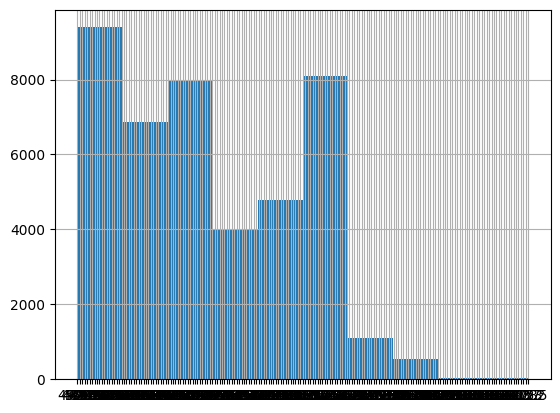

In [ ]:
# Let's check the column names in the DataFrame first
# print(site.columns)

# After checking, it seems there is an extra space at the beginning of the column name.
site['ECU - Exhaust gas temperature (°C)'].hist()
plt.show()

In [ ]:
site_sum = site.groupby(np.arange(len(site.index))//60).mean()
site_sum

In [ ]:
pd.pivot_table(site, values= [' Generator DC voltage (V)', ' Generator DC current - IG (A)', ' Load DC current - IL (A)', ' Generator power (kW)', ' Load power (kW)', ' RPM (From ECU) (rpm)', ' Work hours (h)', ' ECU - Exhaust gas temperature (°C)', ' Fuel level (%)', ' Service hours (h)', ' Expansion board inputs status', ' Oil pressure (bar)'], aggfunc= np.mean)

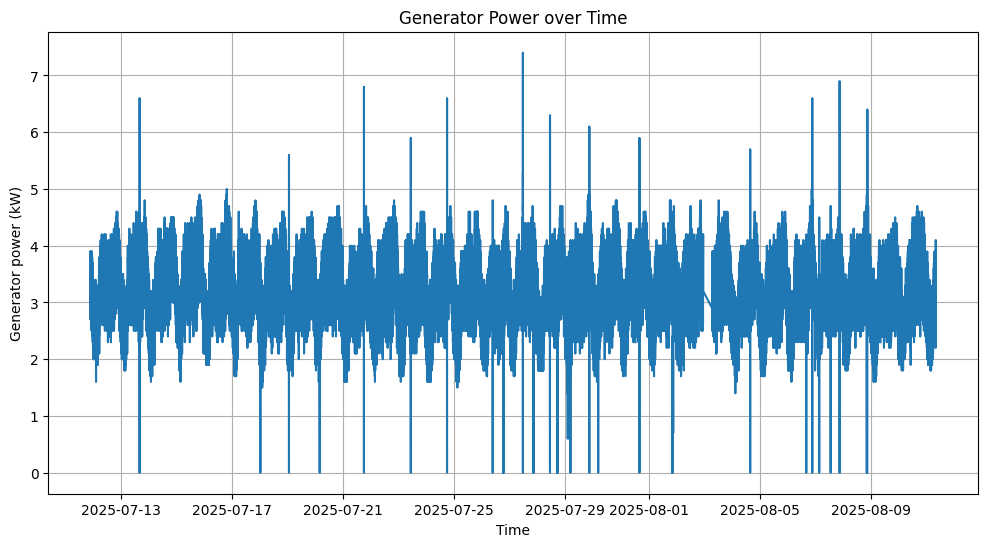

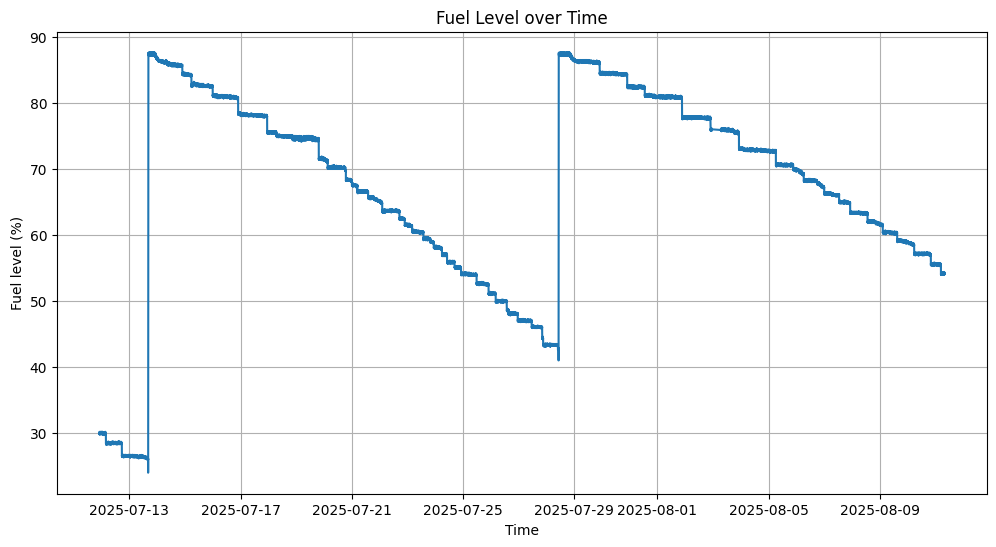

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(site['refresh_time'], site['Generator power (kW)'])
plt.xlabel('Time')
plt.ylabel('Generator power (kW)')
plt.title('Generator Power over Time')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(site['refresh_time'], site['Fuel level (%)'])
plt.xlabel('Time')
plt.ylabel('Fuel level (%)')
plt.title('Fuel Level over Time')
plt.grid(True)
plt.show()

In [ ]:
site['Fuel level change'] = site['Fuel level (%)'].diff()

refueling_events = site[site['Fuel level change'] > 5] # Assuming a change of more than 5% indicates refueling

print("Refueling Events:")
display(refueling_events[['refresh_time', 'Fuel level (%)', 'Fuel level change']])

Refueling Events:


,refresh_time,Fuel level (%),Fuel level change
2538,2025-07-13 16:17:23,34.8,8.9
2539,2025-07-13 16:18:23,43.7,8.9
2540,2025-07-13 16:19:23,52.6,8.9
2541,2025-07-13 16:20:23,61.1,8.5
2542,2025-07-13 16:21:23,68.9,7.8
2543,2025-07-13 16:22:23,75.8,6.9
2544,2025-07-13 16:23:23,81.2,5.4
2545,2025-07-13 16:24:23,87.2,6.0
23617,2025-07-28 10:37:23,52.2,11.2
23618,2025-07-28 10:38:23,62.3,10.1


In [ ]:
# Calculate the time difference between consecutive refueling events
refueling_events['time_diff'] = refueling_events['refresh_time'].diff().dt.total_seconds() / 3600 # in hours

# Calculate the fuel consumed between consecutive refueling events
refueling_events['fuel_consumed'] = -refueling_events['Fuel level change'] # Fuel change is positive for refueling, so consumed is negative of that

# Calculate fuel consumption rate (Fuel consumed per hour)
refueling_events['consumption_rate'] = refueling_events['fuel_consumed'] / refueling_events['time_diff']

print("Fuel Consumption Rate between Refueling Events:")
display(refueling_events[['refresh_time', 'Fuel level (%)', 'Fuel level change', 'time_diff', 'fuel_consumed', 'consumption_rate']].dropna())

Fuel Consumption Rate between Refueling Events:


/tmp/ipython-input-2961970212.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  refueling_events['time_diff'] = refueling_events['refresh_time'].diff().dt.total_seconds() / 3600 # in hours
/tmp/ipython-input-2961970212.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  refueling_events['fuel_consumed'] = -refueling_events['Fuel level change'] # Fuel change is positive for refueling, so consumed is negative of that
/tmp/ipython-input-2961970212.py:8: SettingWithCopyWarning: 
A value is trying to be set on

,refresh_time,Fuel level (%),Fuel level change,time_diff,fuel_consumed,consumption_rate
2539,2025-07-13 16:18:23,43.7,8.9,0.016667,-8.9,-534.0
2540,2025-07-13 16:19:23,52.6,8.9,0.016667,-8.9,-534.0
2541,2025-07-13 16:20:23,61.1,8.5,0.016667,-8.5,-510.0
2542,2025-07-13 16:21:23,68.9,7.8,0.016667,-7.8,-468.0
2543,2025-07-13 16:22:23,75.8,6.9,0.016667,-6.9,-414.0
2544,2025-07-13 16:23:23,81.2,5.4,0.016667,-5.4,-324.0
2545,2025-07-13 16:24:23,87.2,6.0,0.016667,-6.0,-360.0
23617,2025-07-28 10:37:23,52.2,11.2,354.216667,-11.2,-0.031619
23618,2025-07-28 10:38:23,62.3,10.1,0.016667,-10.1,-606.0
23619,2025-07-28 10:39:23,70.5,8.2,0.016667,-8.2,-492.0


In [ ]:
# Identify the indices of refueling events
refueling_indices = refueling_events.index

# Initialize lists to store results
consumption_rates_between_refuels = []
start_times = []
end_times = []
fuel_consumed_between = []
time_diffs_between = []

# Iterate through the periods between refueling events
for i in range(len(refueling_indices) - 1):
    start_index = refueling_indices[i]
    end_index = refueling_indices[i+1]

    # Select the data between the two refueling events
    period_data = site.loc[start_index:end_index]

    # Calculate the fuel level change during this period (should be negative)
    fuel_change = period_data['Fuel level (%)'].iloc[-1] - period_data['Fuel level (%)'].iloc[0]

    # Calculate the time difference in hours
    time_diff = (period_data['refresh_time'].iloc[-1] - period_data['refresh_time'].iloc[0]).total_seconds() / 3600

    # Calculate consumption rate if time difference is not zero and fuel change is negative
    if time_diff > 0 and fuel_change < 0:
        consumption_rate = -fuel_change / time_diff  # Consumption rate should be positive

        start_times.append(period_data['refresh_time'].iloc[0])
        end_times.append(period_data['refresh_time'].iloc[-1])
        fuel_consumed_between.append(-fuel_change)
        time_diffs_between.append(time_diff)
        consumption_rates_between_refuels.append(consumption_rate)

# Create a DataFrame to display the results
consumption_df = pd.DataFrame({
    'Start Time': start_times,
    'End Time': end_times,
    'Fuel Consumed (%)': fuel_consumed_between,
    'Time Elapsed (hours)': time_diffs_between,
    'Consumption Rate (%/hour)': consumption_rates_between_refuels
})

print("Fuel Consumption Rate Between Refueling Events:")
display(consumption_df)

Fuel Consumption Rate Between Refueling Events:


,Start Time,End Time,Fuel Consumed (%),Time Elapsed (hours),Consumption Rate (%/hour)
0,2025-07-13 16:24:23,2025-07-28 10:37:23,35.0,354.216667,0.09881


In [ ]:
# Calculate the average generator power during each period between refueling events
average_power_between_refuels = []

# Iterate through the periods that are included in consumption_df
for index, row in consumption_df.iterrows():
    start_time = row['Start Time']
    end_time = row['End Time']

    # Select the data for the specific period from the original site DataFrame
    period_data = site[(site['refresh_time'] >= start_time) & (site['refresh_time'] <= end_time)]

    # Calculate the average generator power for the period
    average_power = period_data['Generator power (kW)'].mean()
    average_power_between_refuels.append(average_power)

# Add the average power to the consumption_df DataFrame
consumption_df['Average Generator Power (kW)'] = average_power_between_refuels

print("Fuel Consumption Rate and Average Generator Power Between Refueling Events:")
display(consumption_df)

# You can also calculate the correlation between consumption rate and average power
correlation = consumption_df['Consumption Rate (%/hour)'].corr(consumption_df['Average Generator Power (kW)'])
print(f"\nCorrelation between Consumption Rate and Average Generator Power: {correlation}")

Fuel Consumption Rate and Average Generator Power Between Refueling Events:


,Start Time,End Time,Fuel Consumed (%),Time Elapsed (hours),Consumption Rate (%/hour),Average Generator Power (kW)
0,2025-07-13 16:24:23,2025-07-28 10:37:23,35.0,354.216667,0.09881,3.171733



Correlation between Consumption Rate and Average Generator Power: nan


/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


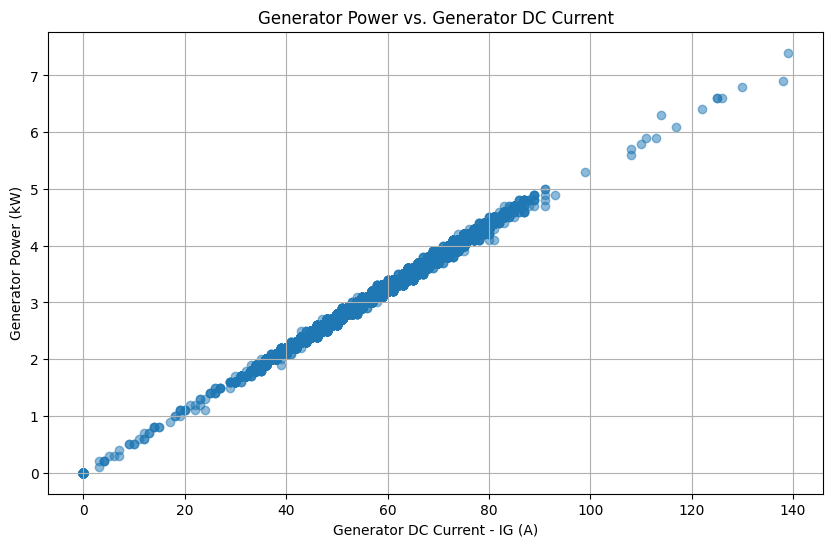

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(site['Generator DC current - IG (A)'], site['Generator power (kW)'], alpha=0.5)
plt.xlabel('Generator DC Current - IG (A)')
plt.ylabel('Generator Power (kW)')
plt.title('Generator Power vs. Generator DC Current')
plt.grid(True)
plt.show()

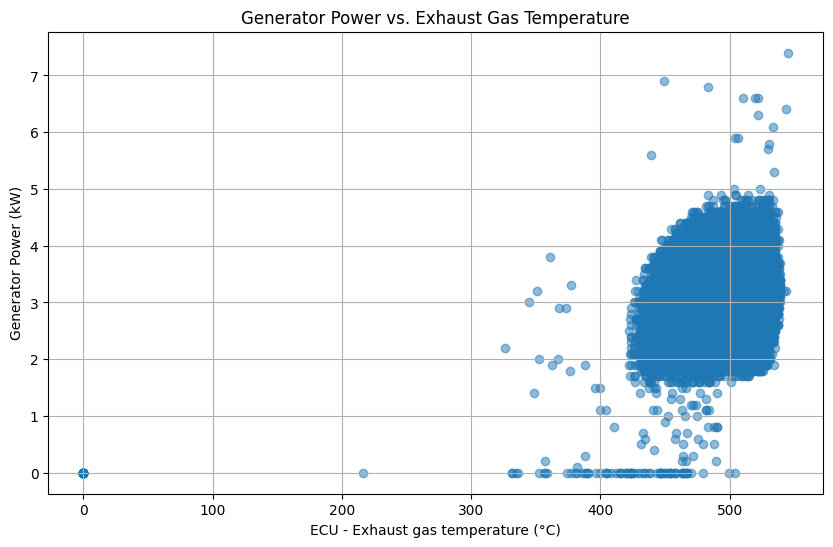

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(site['ECU - Exhaust gas temperature (°C)'], site['Generator power (kW)'], alpha=0.5)
plt.xlabel('ECU - Exhaust gas temperature (°C)')
plt.ylabel('Generator Power (kW)')
plt.title('Generator Power vs. Exhaust Gas Temperature')
plt.grid(True)
plt.show()

Data within the exhaust temperature cluster (450°C - 520°C):


,refresh_time
count,36759
mean,2025-07-26 15:11:07.984901888
min,2025-07-11 21:58:23
25%,2025-07-18 22:08:53
50%,2025-07-25 16:54:23
75%,2025-08-03 15:16:53
max,2025-08-11 07:54:23


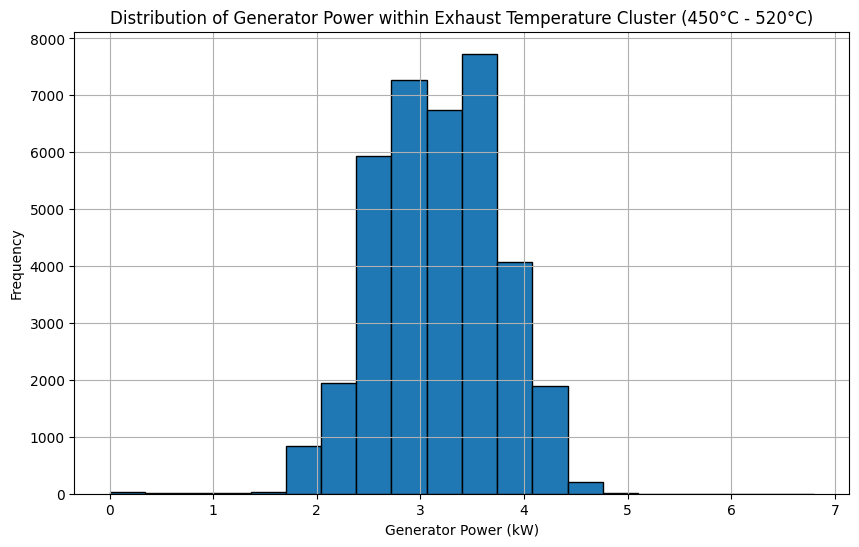

In [ ]:
# Filter the data for the specified temperature range
temperature_cluster_data = site[(site['ECU - Exhaust gas temperature (°C)'] >= 450) & (site['ECU - Exhaust gas temperature (°C)'] <= 520)]

print("Data within the exhaust temperature cluster (450°C - 520°C):")
display(temperature_cluster_data.describe())

# Plot a histogram of Generator Power within this cluster
plt.figure(figsize=(10, 6))
plt.hist(temperature_cluster_data['Generator power (kW)'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Generator Power (kW)')
plt.ylabel('Frequency')
plt.title('Distribution of Generator Power within Exhaust Temperature Cluster (450°C - 520°C)')
plt.grid(True)
plt.show()

Data within the exhaust temperature cluster (200°C - 430°C):


,refresh_time
count,112
mean,2025-07-24 21:48:34.785714432
min,2025-07-13 16:25:23
25%,2025-07-16 02:41:53
50%,2025-07-28 16:51:53
75%,2025-07-28 17:19:38
max,2025-08-08 20:44:23


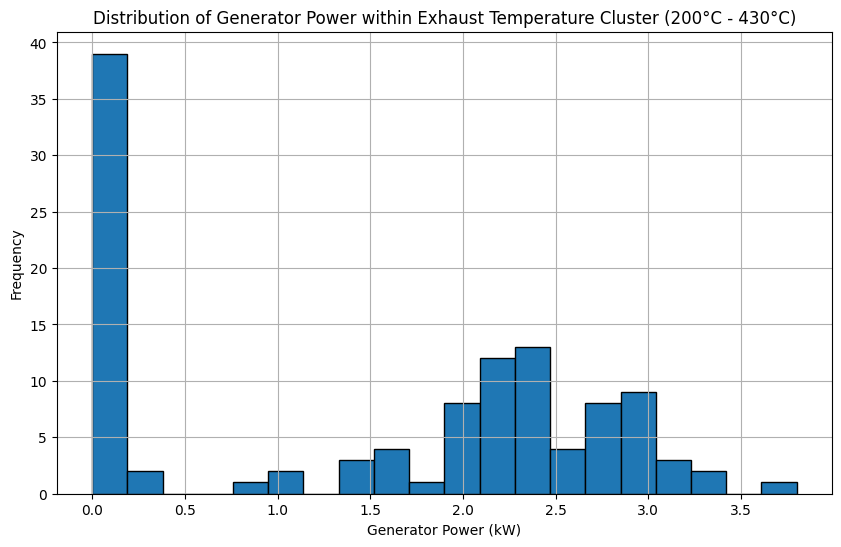

In [ ]:
# Filter the data for the specified temperature range
temperature_cluster_data_200_430 = site[(site['ECU - Exhaust gas temperature (°C)'] >= 200) & (site['ECU - Exhaust gas temperature (°C)'] <= 430)]

print("Data within the exhaust temperature cluster (200°C - 430°C):")
display(temperature_cluster_data_200_430.describe())

# Plot a histogram of Generator Power within this cluster
plt.figure(figsize=(10, 6))
plt.hist(temperature_cluster_data_200_430['Generator power (kW)'].dropna(), bins=20, edgecolor='black')
plt.xlabel('Generator Power (kW)')
plt.ylabel('Frequency')
plt.title('Distribution of Generator Power within Exhaust Temperature Cluster (200°C - 430°C)')
plt.grid(True)
plt.show()

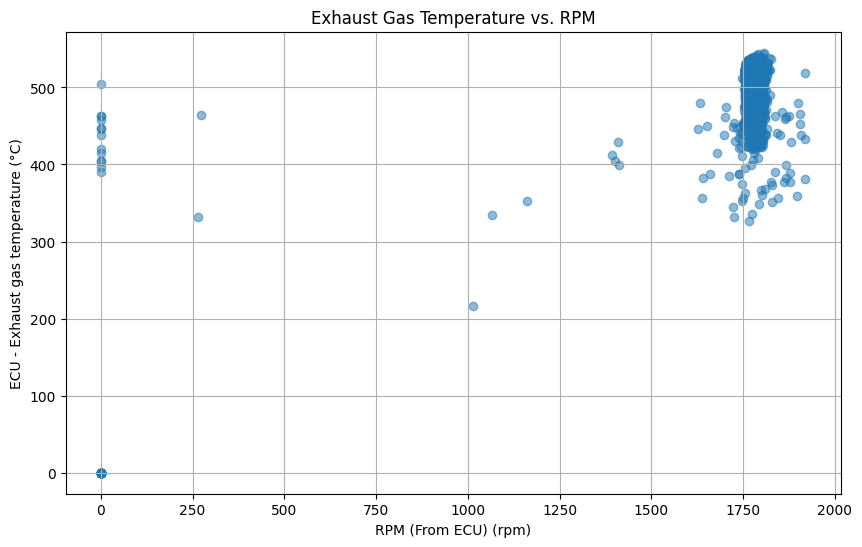

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(site['RPM (From ECU) (rpm)'], site['ECU - Exhaust gas temperature (°C)'], alpha=0.5)
plt.xlabel('RPM (From ECU) (rpm)')
plt.ylabel('ECU - Exhaust gas temperature (°C)')
plt.title('Exhaust Gas Temperature vs. RPM')
plt.grid(True)
plt.show()

In [ ]:
# Separate data into high and low RPM groups
high_rpm_data = site[site['RPM (From ECU) (rpm)'] > 1500]
low_rpm_data = site[site['RPM (From ECU) (rpm)'] <= 1500]

print("Descriptive Statistics for High RPM Data (RPM > 1500):")
display(high_rpm_data.describe())

print("\nDescriptive Statistics for Low RPM Data (RPM <= 1500):")
display(low_rpm_data.describe())

Descriptive Statistics for High RPM Data (RPM > 1500):


,refresh_time
count,42756
mean,2025-07-27 01:08:22.987369984
min,2025-07-11 21:58:23
25%,2025-07-19 11:20:08
50%,2025-07-26 22:33:53
75%,2025-08-03 19:39:38
max,2025-08-11 07:54:23



Descriptive Statistics for Low RPM Data (RPM <= 1500):


,refresh_time
count,47
mean,2025-07-29 01:54:49.808510720
min,2025-07-13 16:25:23
25%,2025-07-24 02:11:23
50%,2025-07-28 10:44:23
75%,2025-08-04 15:34:53
max,2025-08-08 20:44:23
